In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper

In [2]:
atom_string = f"H 0 0 0; H 0 0 {0.25}"

driver = PySCFDriver(
    atom=atom_string,
    basis='sto3g', # Menggunakan dict kustom
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

es_problem = driver.run()
second_q_op = es_problem.hamiltonian.second_q_op()

# mapper = ParityMapper(num_particles=es_problem.num_particles)
mapper = JordanWignerMapper()
# mapper = BravyiKitaevMapper()
qubit_op = mapper.map(second_q_op)

In [13]:
df = pd.read_csv('../input/test_data/test_data_jw_custom.csv')

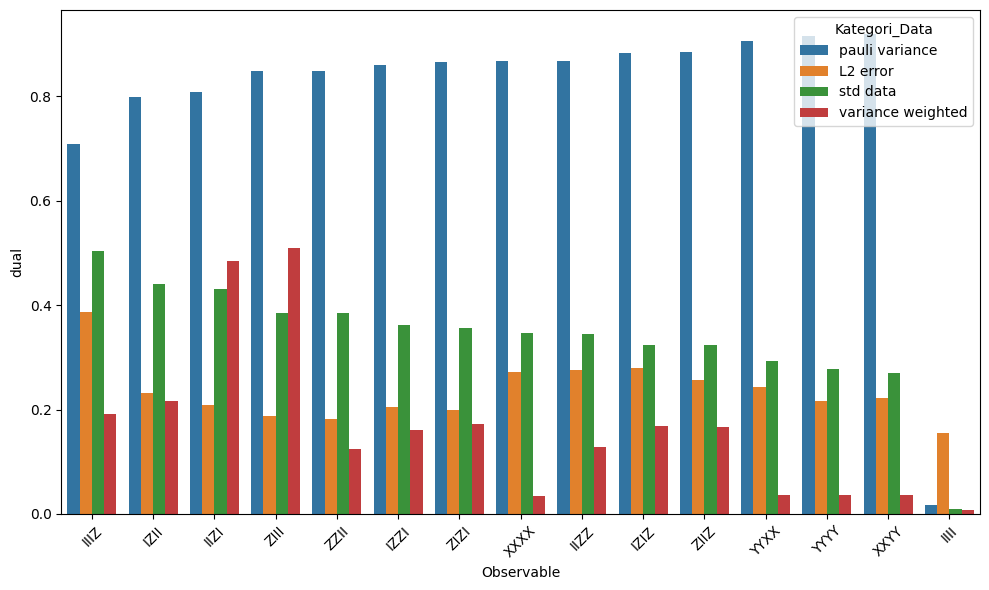

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


params = [f'param_{i}' for i in range(12)]
target = 'ideal_energy'
observables = df['observable'].unique()

df["pred_abs_err"] = (df['noisy_energy'] - df["ideal_energy"])**2
df['variance'] = 1-(df[target])**2

# Table to store partial derivative estimates (slopes)
obs_variance = []

for obs,coeff in qubit_op.to_list():
    
    obs_df = df[df['observable'] == obs]
    
    # Get the variance of the target column
    variance = (obs_df['variance']).abs().mean()
    variance_weight = (coeff.real*obs_df['variance']).abs().mean()
    L2 = obs_df["pred_abs_err"].sum()
    variansi = obs_df['noisy_energy'].std()
    # Optionally store it in your list
    obs_variance.append({'dataset': obs, 'pauli variance': variance, 'L2 error' : np.sqrt(L2), 'std data': variansi, 
                         'variance weighted': variance_weight})

# 2. Create a summary DataFrame for plotting
variance_df = pd.DataFrame(obs_variance).sort_values(by='std data', ascending=False)
melt_df = variance_df.melt(id_vars='dataset', 
                           value_vars=['pauli variance', 'L2 error','std data', 'variance weighted'], 
                           var_name='Kategori_Data', 
                           value_name='dual')
# 3. Create the plot
plot= 'dual'
plt.figure(figsize=(10, 6))
sns.barplot(data=melt_df, x='dataset', y=plot,hue='Kategori_Data')

# plt.title(f'Variance of {target} by Observable')
plt.xlabel('Observable')
plt.ylabel(plot)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()